In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [53]:
df = pd.read_excel('/content/Copy of Dataset_AQI25-4.xlsx')

In [54]:
df.head()



,City,AQI,PM2.5,PM10,O3,NO2,SO2,CO,Latitude,Longitude,Time
0,"Gulzarpet, Anantapur, India",92,92.0,39.0,22.2,4.4,3.3,4.5,14.675886,77.593027,2024-04-25 14:00:00
1,"Anand Kala Kshetram, Rajamahendravaram, India",55,55.0,52.0,12.7,10.7,4.9,6.0,16.987287,81.736318,2024-04-25 14:00:00
2,"Tirumala-APPCB, Tirupati, India",112,112.0,61.0,31.3,8.8,4.1,6.9,13.670000,79.350000,2024-04-25 14:00:00
3,"PWD Grounds, Vijayawada, India",-,52.0,NaN,5.1,0.7,4.9,4.2,16.507014,80.627767,2020-11-19 16:00:00
4,"Naharlagun, Naharlagun, India",51,51.0,20.0,1.0,1.1,1.6,2.1,27.103358,93.679645,2024-04-25 13:00:00


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   City       153 non-null    object 
 1   AQI        153 non-null    object 
 2   PM2.5      148 non-null    float64
 3   PM10       137 non-null    float64
 4   O3         132 non-null    float64
 5   NO2        141 non-null    float64
 6   SO2        137 non-null    float64
 7   CO         133 non-null    float64
 8   Latitude   153 non-null    float64
 9   Longitude  153 non-null    float64
 10  Time       152 non-null    object 
dtypes: float64(8), object(3)
memory usage: 13.3+ KB


In [56]:
df.describe()

,PM2.5,PM10,O3,NO2,SO2,CO,Latitude,Longitude
count,148.000000,137.000000,132.00000,141.000000,137.000000,133.000000,153.000000,153.000000
mean,106.479730,93.452555,23.24697,8.519149,10.085401,5.966165,24.192362,77.217847
std,79.246148,129.012937,17.91751,17.205331,20.267536,5.651788,7.923463,22.282408
min,9.000000,4.000000,1.00000,0.100000,0.200000,0.100000,8.514909,-123.005934
25%,59.000000,46.000000,8.17500,2.700000,3.100000,3.200000,20.007328,75.905200
50%,87.000000,61.000000,18.10000,5.800000,5.100000,4.500000,25.204762,77.984321
75%,126.250000,86.000000,35.07500,10.000000,9.600000,7.200000,28.406963,84.663264
max,511.000000,954.000000,81.60000,198.000000,216.600000,51.000000,53.589040,142.947970


In [57]:
df.isnull().sum()

,0
City,0
AQI,0
PM2.5,5
PM10,16
O3,21
NO2,12
SO2,16
CO,20
Latitude,0
Longitude,0


now we have to convert AQI into NUmeric column and then we plot heat map

In [58]:
df['AQI'] = pd.to_numeric(df['AQI'], errors='coerce')  # explaination of this code
                                                       # df['AQI] this select the AQI named column o from the dataframe
                                                       # pd.to_numeric() this is pandas fucntion which converts any data type into numeric
                                                       # errors=:"coerce" this is so important bcs if there is a value that can be converted into
                                                       # numeric then errors=:"coerce" changed that invelid value into NaN is this parameter is not there
                                                       # then code whould error on invalid value

In [59]:
df.info()                         # we are cheacking the AQI column again if its changed into numeric or not


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   City       153 non-null    object 
 1   AQI        150 non-null    float64
 2   PM2.5      148 non-null    float64
 3   PM10       137 non-null    float64
 4   O3         132 non-null    float64
 5   NO2        141 non-null    float64
 6   SO2        137 non-null    float64
 7   CO         133 non-null    float64
 8   Latitude   153 non-null    float64
 9   Longitude  153 non-null    float64
 10  Time       152 non-null    object 
dtypes: float64(9), object(2)
memory usage: 13.3+ KB


In [60]:
df['AQI'].head()

,AQI
0,92.0
1,55.0
2,112.0
3,NaN
4,51.0


In [61]:
df['AQI'].dtype

dtype('float64')

Next step Building heat map to cheack which polution effecting  the AQI most

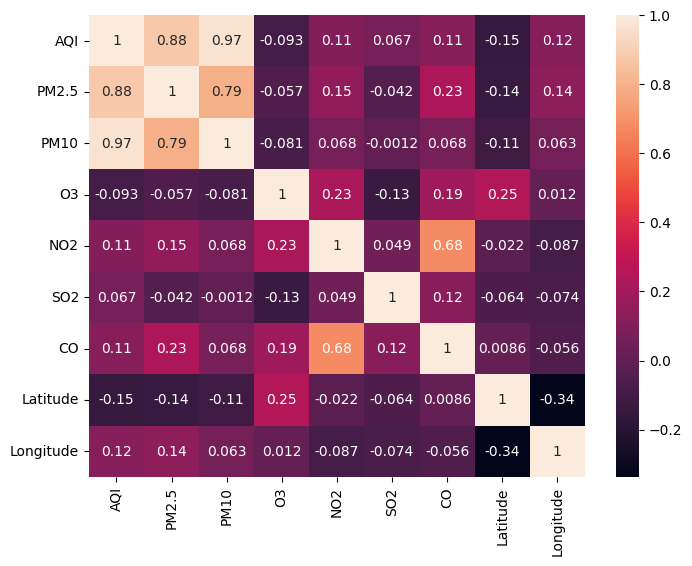

In [62]:
numeric_df = df.select_dtypes(include=['float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

# we can see that PM10 is highly correlated with AQI and THEN PM2.5 is also highly corelated with AQI means is these two increases AQI will increas and Other features like NO3,CO have week correlation with AQI
there is one important detail we can observe by heat map is that PM2.5 and PM10 is also correlated with each other
(0.779) it creates multicollinearity which will effect the model

In [63]:
# now we going to train our model


In [64]:
df.fillna(df.mean(numeric_only=True), inplace=True)     #1st we have to fill the missing values
                                                        #This code fills missing values (NaN) in the DataFrame df:

                                                        #df.fillna(): Replaces missing values.
                                                        #df.mean(numeric_only=True): Calculates the mean (average)
                                                        #of only the numeric columns in df.
                                                        #inplace=True: Applies these changes directly to the original df DataFrame.

In [65]:
df.info()                                    # no null shown  in the output

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   City       153 non-null    object 
 1   AQI        153 non-null    float64
 2   PM2.5      153 non-null    float64
 3   PM10       153 non-null    float64
 4   O3         153 non-null    float64
 5   NO2        153 non-null    float64
 6   SO2        153 non-null    float64
 7   CO         153 non-null    float64
 8   Latitude   153 non-null    float64
 9   Longitude  153 non-null    float64
 10  Time       152 non-null    object 
dtypes: float64(9), object(2)
memory usage: 13.3+ KB


NOW WE GOING TO DECIDE FEATURE AND TARGET

In [66]:
X = df[['PM10', 'PM2.5']]
y = df['AQI']

NEXT WE GPING TO SPLIT IT INTO TRAIN AND TEST


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
X_train.head()

,PM10,PM2.5
94,683.000000,430.0
68,39.000000,64.0
22,220.000000,229.0
45,93.452555,76.0
76,36.000000,50.0


In [69]:
X_test.head()

,PM10,PM2.5
84,38.0,82.0
86,52.0,45.0
97,61.0,57.0
115,53.0,79.0
29,51.0,67.0


In [70]:
y_train.head()

,AQI
94,683.0
68,217.0
22,229.0
45,76.0
76,50.0


NOW WE GOING TO TRAIN MODEL

In [71]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [72]:
y_pred_linear = model.predict(X_test)

In [73]:
y_pred

array([ 78.78906796,  49.5443161 ,  66.11251416,  77.04303201,
        69.98747628, 133.31382779, 114.97014261, 151.14609657,
       216.87090429, 206.84973572,  90.41659913, 136.48911616,
       311.56115473,  67.34549786, 113.06108033, 119.63392698,
        93.40384328, 112.41948436,  94.36330126, 491.25319548,
        68.21324621, 114.72370767,  69.98747628,  60.78665101,
        58.71362637,  64.8819144 ,  66.60123621,  65.38452229,
       115.03153643,  74.26322242, 156.32845185])

In [74]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 174.12833508492477
R2 Score: 0.9785244785109732


LETS ADD MORE FEATURES

In [75]:
X = df[['PM10', 'PM2.5', 'NO2', 'CO']]

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(                    # here we have to do train test split gain bcs more features were added
    X, y, test_size=0.2, random_state=42
)

In [77]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [78]:
y_pred_linear = model.predict(X_test)

In [79]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 174.12833508492477
R2: 0.9785244785109732


MSE DECRESES FROM 632 → 588 that means errors were redecued    and R2 increases 0.92 → 0.927 that means model performes very good

CONCLUSION
PM10 + PM2.5 best simple model
PM10 + PM2.5 + NO2 + CO sightly better model

NEXT STEP IS TO CHEACK WHICH FEATURES IS HOW MUCH POWERFUL


In [80]:
print("Features:", X.columns)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Features: Index(['PM10', 'PM2.5', 'NO2', 'CO'], dtype='object')
Coefficients: [ 0.70982223  0.56640907  0.12613569 -0.47360364]
Intercept: -4.076845947249879


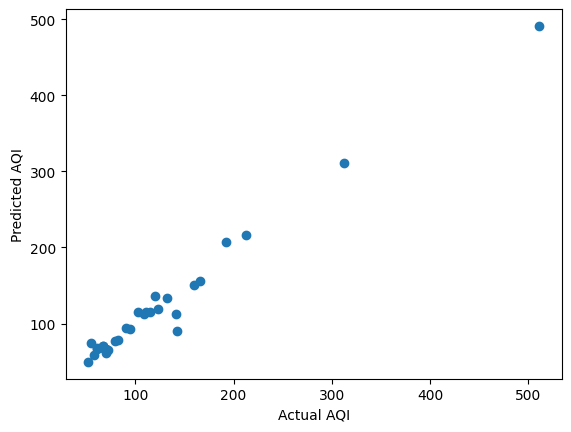

In [81]:
import matplotlib.pyplot as plt                                #actual vs predicted graph

plt.scatter(y_test, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.show()

NEXT RESEDUAL ANALYSIS

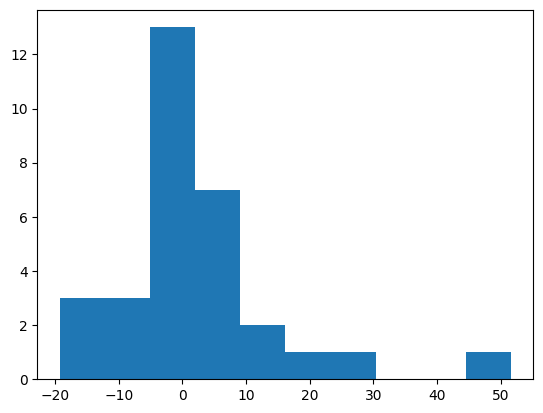

In [82]:
residuals = y_test - y_pred

plt.hist(residuals)
plt.show()

# now we going to train the poly reg to make model more better and accurate


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [83]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

In [84]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

TRAINING MODEL

In [85]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [86]:
y_pred_poly = model.predict(X_test_poly)

In [87]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 174.12833508492477
R2: 0.9785244785109732


WE CAN CLEARLY SE THIS THAT MODEL BECOMES MORE BETTER AS
MSE: 174.12833508492477 (DECREASES)

*   MSE: 174.12833508492477 (DECREASES)
*   R2: 0.9785244785109732  (INCREASES)


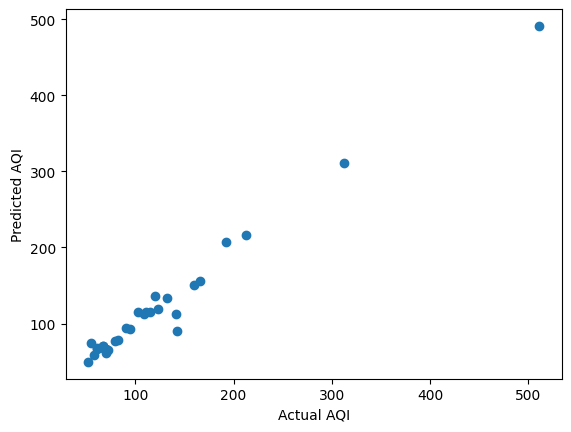

In [88]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.show()

COMPARING LINEAR REGG AND POLY REGG

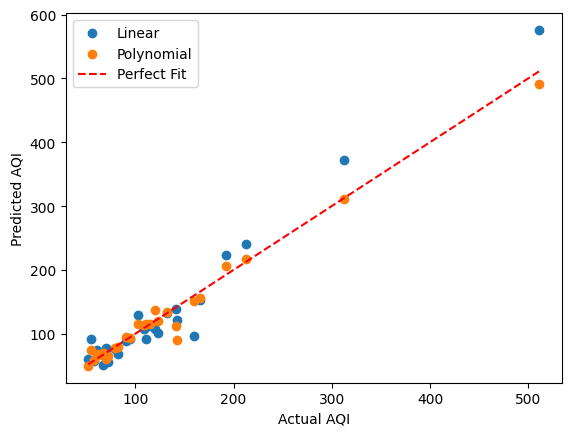

In [90]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_linear, label="Linear")
plt.scatter(y_test, y_pred_poly, label="Polynomial")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Fit')

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.legend()
plt.show()

Polynomial is performing better


PM10 and PM2.5 were found to be the most influential factors affecting AQI.

PM10 showed the strongest correlation (~0.97), followed by PM2.5 (~0.88), indicating that particulate matter is the primary contributor to air pollution levels.

A strong correlation (~0.79) was observed between PM10 and PM2.5, indicating multicollinearity.

This suggests that both variables carry overlapping information about air pollution.

Linear Regression achieved an R² score of ~0.92, indicating strong predictive capability.

Polynomial Regression slightly improved performance (R² ~0.97), showing that AQI has some non-linear relationships with pollutants.

The model confirms that particulate matter (PM10 & PM2.5) is the dominant factor in determining air quality.

This aligns with real-world environmental studies where fine particles are the major cause of poor air quality.